In [1]:
import json

import duckdb
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from lending_pd.config import (CATEGORICAL_FEATURES, DB_PATH, MODEL_A_FEATURES, MODEL_B_EXTRA, ROOT)
from lending_pd.train import (add_state_grp, load_engineered, temporal_split, to_categorical)

FIG = ROOT / "reports" / "figures"

metrics = json.loads((ROOT / "reports" / "metrics.json").read_text())

models = {name: joblib.load(ROOT / "models" / f"{name}.joblib") for name in ["logistic_A", "logistic_B", "lgbm_A", "lgbm_B"]}

df = load_engineered()
train, test = temporal_split(df)
train, test = add_state_grp(train, test)
y_te = test["default_flag"]


In [2]:
def model_columns(features, categorical):
    numeric = [f for f in features if f not in categorical]
    return numeric + categorical

cols_A = model_columns(MODEL_A_FEATURES, CATEGORICAL_FEATURES)
cols_B = model_columns(MODEL_A_FEATURES + MODEL_B_EXTRA,
                       CATEGORICAL_FEATURES + ["sub_grade"])

_, test_A = to_categorical(train[cols_A], test[cols_A], CATEGORICAL_FEATURES)
_, test_B = to_categorical(train[cols_B], test[cols_B], CATEGORICAL_FEATURES + ["sub_grade"])

preds = {
    "logistic_A": models["logistic_A"].predict_proba(test_A)[:, 1],
    "logistic_B": models["logistic_B"].predict_proba(test_B)[:, 1],
    "lgbm_A": models["lgbm_A"].predict_proba(test_A)[:, 1],
    "lgbm_B": models["lgbm_B"].predict_proba(test_B)[:, 1],
}

assert abs(preds["lgbm_A"].mean() - 0.1310) < 0.0005
assert abs(preds["logistic_A"].mean() - 0.1347) <0.0005

LGBM_A Out-of-time calibration test:

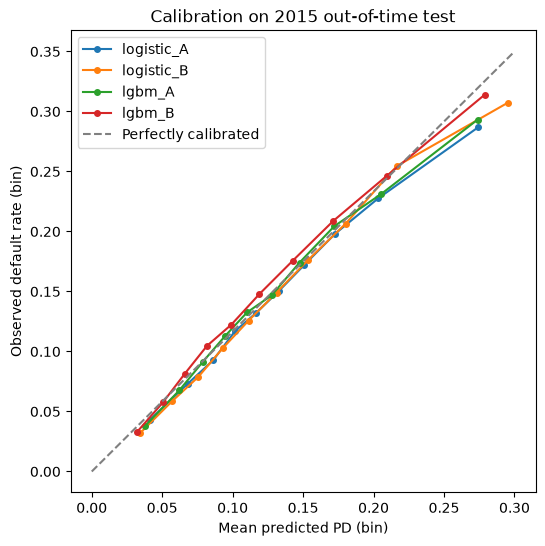

In [3]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(6, 6))
for name, p in preds.items():
    frac_pos, mean_pred = calibration_curve(y_te, p, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", ms=4, label=name)
ax.plot([0,0.3], [0,0.35], "--", color="gray", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted PD (bin)"); ax.set_ylabel("Observed default rate (bin)")
ax.set_title("Calibration on 2015 out-of-time test"); ax.legend()
fig.savefig(FIG / "calibration_oot.png", dpi=150, bbox_inches="tight")
plt.show()

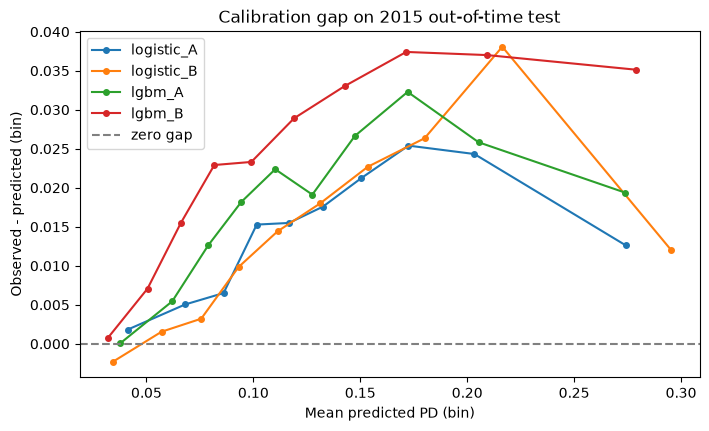

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for name, p in preds.items():
    frac_pos, mean_pred = calibration_curve(y_te, p, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos - mean_pred, marker="o", ms=4, label=name)
ax.axhline(0, ls="--", color="gray", label="zero gap")
ax.set_xlabel("Mean predicted PD (bin)"); ax.set_ylabel("Observed - predicted (bin)")
ax.set_title("Calibration gap on 2015 out-of-time test"); ax.legend()
fig.savefig(FIG / "calibration_gap_oot.png", dpi=150, bbox_inches="tight")
plt.show()  

Out-of-time calibration gap is not uniform: near-zero in the safest bins peaking at +3-4pts through the 0.10-0.20 PD range, narrowing in the top decile. Drift concentrated in the middle of risk distribution. Model ordering matches training-window recency (lgbm_B trained on earliest drifts the most). Top decile gaps vary across models with tail membership and are to be read cautiously despite ~19k loans per bin.

ROC overlay or how the five scores compare on ranking ability:

<function matplotlib.pyplot.show(close=None, block=None)>

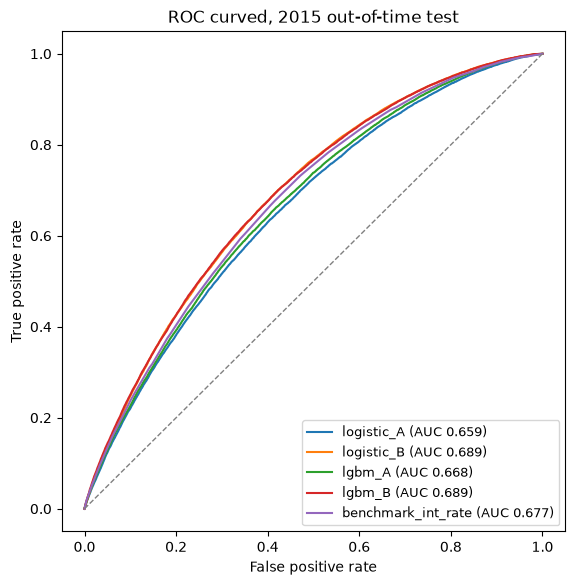

In [5]:
from sklearn.metrics import roc_curve

scores = dict(preds)
scores["benchmark_int_rate"] = test["int_rate"].to_numpy()

auc_lookup = {m["model"].replace("_alone", ""): m["roc_auc"] for m in metrics}
auc_lookup["benchmark_int_rate"] = auc_lookup.pop("benchmark_int_rate")

fig, ax = plt.subplots(figsize=(6.5,6.5))
for name, s in scores.items():
    fpr, tpr, _ = roc_curve(y_te, s)
    ax.plot(fpr, tpr, lw=1.5, label=f"{name} (AUC {auc_lookup[name]:.3f})")
ax.plot([0,1], [0,1], "--", color='gray', lw=1)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curved, 2015 out-of-time test")
ax.legend(loc="lower right", fontsize=9)
fig.savefig(FIG / "roc_oot.png", dpi=150, bbox_inches="tight")
plt.show

Takeaways: Scores span just 3 AUC points (0.659-0.689). The B pair is visually indistinguishable.

Logistic A coefficients or attribute-only drivers and missingness:

num__missingindicator_revol_util                0.014924
num__missingindicator_emp_length_yrs            0.039543
num__missingindicator_mths_since_last_delinq    0.046445
dtype: float64


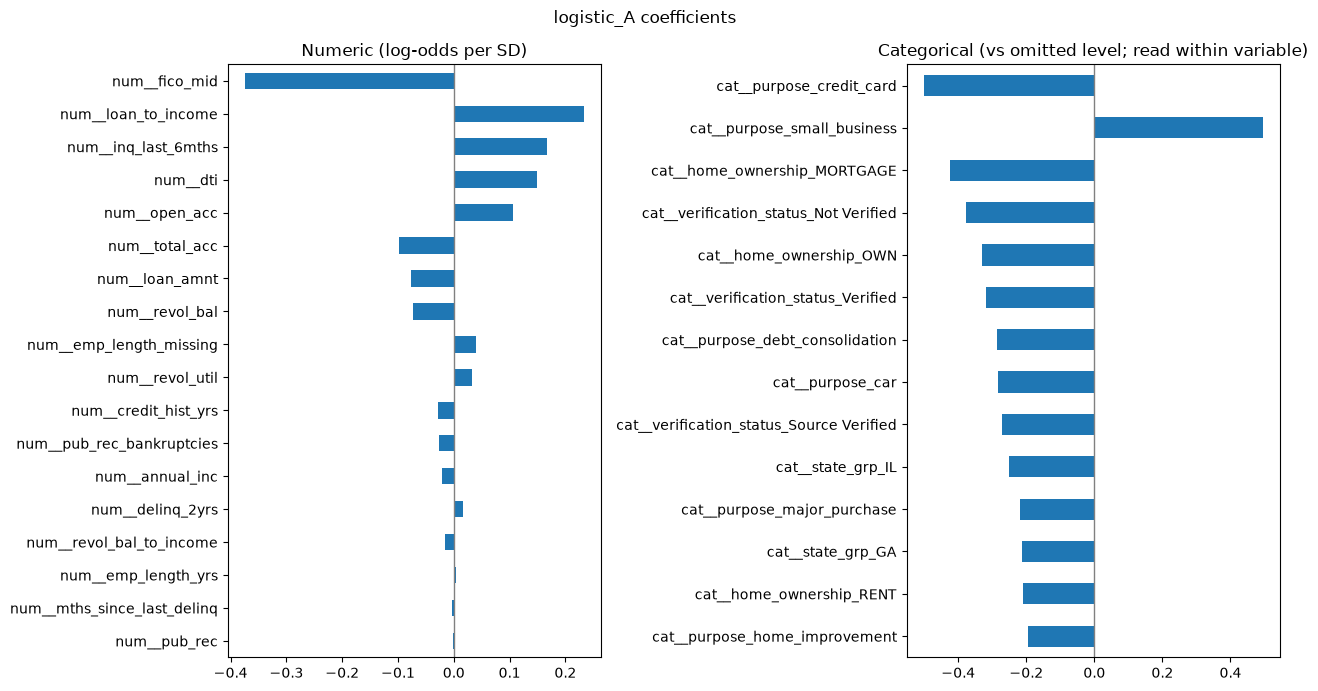

In [6]:
pipe = models["logistic_A"]
names = pipe.named_steps["pre"].get_feature_names_out()
coefs = pd.Series(pipe.named_steps["clf"].coef_[0], index=names)

num_coefs = coefs[coefs.index.str.startswith("num__")]
num_coefs = num_coefs[~num_coefs.index.str.contains("missingindicator")]
cat_coefs = coefs[coefs.index.str.startswith("cat__")]

fig, axes = plt.subplots(1, 2, figsize=(13,7))
num_coefs.reindex(num_coefs.abs().sort_values().index).plot.barh(ax=axes[0])
axes[0].set_title("Numeric (log-odds per SD)")
top_cat = cat_coefs.reindex(cat_coefs.abs().sort_values(ascending=False).index).head(14)
top_cat.iloc[::-1].plot.barh(ax=axes[1])
axes[1].set_title("Categorical (vs omitted level; read within variable)")
for ax in axes:
    ax.axvline(0, color='gray', lw=1)
fig.suptitle("logistic_A coefficients")
fig.tight_layout()
fig.savefig(FIG / "logistic_A_coefficients.png", dpi=150, bbox_inches="tight")
plt.show

print(coefs[coefs.index.str.contains("missingindicator")].sort_values())


Takeaways: numeric coefficients confirm EDA gradients on a common per-SD scale (FICO protective at -0.38/SD; loan_to_income, inquiries and DTI adverse). Categorical contrasts are read within-variable. State effects are retained for analysis but flagged as fair-lending-sensitive in production contexts. All three missingness indicators are positive conditional on attributes, agreeing with indicator-based imputation.

LightGBM gain importances or where the tree model found gains over logistic:

<function matplotlib.pyplot.show(close=None, block=None)>

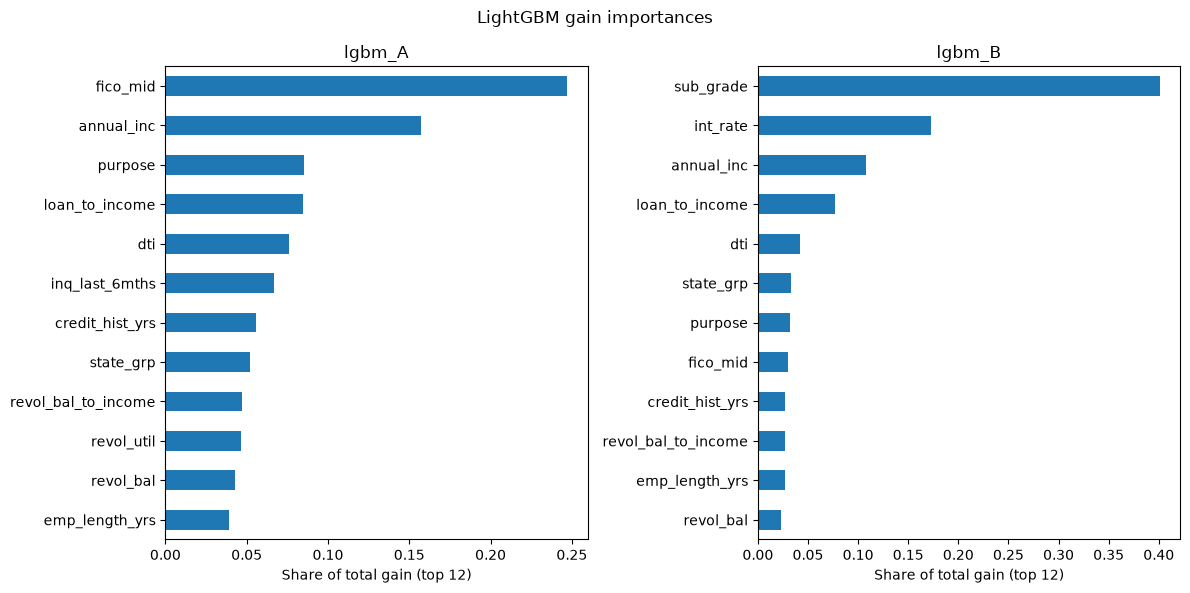

In [7]:
def gain_series(model):
    booster = model.booster_
    return pd.Series(booster.feature_importance(importance_type="gain"),
                     index = booster.feature_name()).sort_values()

fig, axes = plt.subplots(1,2,figsize=(12,6))
for ax, name in zip(axes, ["lgbm_A", "lgbm_B"]):
    g = gain_series(models[name]).tail(12)
    (g / g.sum()).plot.barh(ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Share of total gain (top 12)")
fig.suptitle("LightGBM gain importances")
fig.tight_layout()
fig.savefig(FIG / "lgbm_gain_importances.png", dpi=150, bbox_inches="tight")
plt.show

Takeaways: lgbm_A's gain concentrates in FICO, DTI and purpose over lgbm_B where the platform's sub_grade and int_rate absorb most gain. These lgbm_B pricing features already encode the attribute signal so model class stops mattering as much after their inclusion.